# CarmPom — Model Analysis & 2026 Team Rankings

Visualizes:
- Feature importance from the trained LightGBM model
- Model performance vs KenPom baseline across seasons
- 2026 team rankings by CarmPom AdjEM


## 1. Imports & Setup


In [4]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Make sure project root is on the path so we can import our modules
ROOT = Path(".")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from db.database import SessionLocal
from db.models import CarmPomRating, Team
from ml.features import FEATURE_COLS, build_training_features

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130


## 2. Load model & training data


In [5]:
# Load the best trained model
model_path = ROOT / "data" / "models" / "best.pkl"
with open(model_path, "rb") as f:
    model = pickle.load(f)

print(f"Model type: {type(model).__name__}")

# Build full feature matrix (all seasons)
print("Building feature matrix — takes ~10 seconds...")
features_df = build_training_features(min_season=2003, max_season=2025)
print(f"Loaded {len(features_df):,} tournament games across {features_df['Season'].nunique()} seasons")
print(f"\nFeature columns: {FEATURE_COLS}")


Model type: LGBMClassifier
Building feature matrix — takes ~10 seconds...
Loaded 1,449 tournament games across 22 seasons

Feature columns: ['seed_diff', 'kenpom_rank_diff', 'win_pct_diff', 'pyth_wp_diff', 'adjem_diff', 'efg_diff', 'to_rate_diff', 'or_pct_diff', 'ft_rate_diff']


## 3. Feature Importance

What does the model actually rely on to predict tournament outcomes?


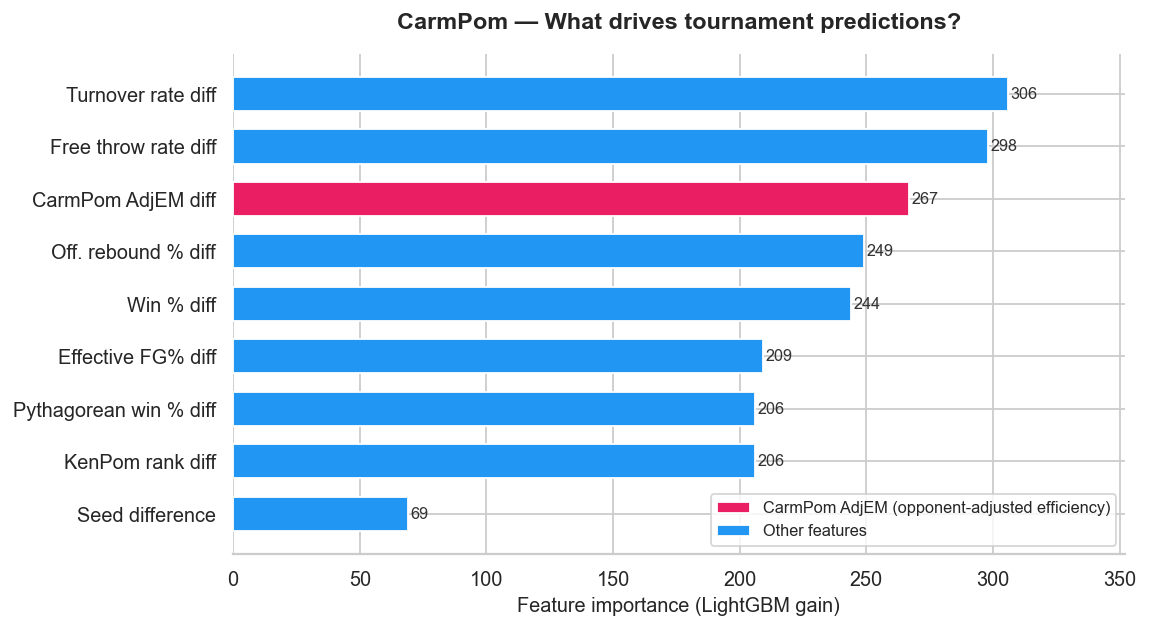

In [6]:
import lightgbm as lgb

# Human-readable feature labels
FEATURE_LABELS = {
    "seed_diff":        "Seed difference",
    "kenpom_rank_diff": "KenPom rank diff",
    "win_pct_diff":     "Win % diff",
    "pyth_wp_diff":     "Pythagorean win % diff",
    "adjem_diff":       "CarmPom AdjEM diff",
    "efg_diff":         "Effective FG% diff",
    "to_rate_diff":     "Turnover rate diff",
    "or_pct_diff":      "Off. rebound % diff",
    "ft_rate_diff":     "Free throw rate diff",
}

# Extract importances — LightGBM exposes feature_importances_ directly
importances = model.feature_importances_
feat_imp = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})
    .assign(label=lambda d: d["feature"].map(FEATURE_LABELS))
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2196F3" if f != "adjem_diff" else "#E91E63" for f in feat_imp["feature"]]
bars = ax.barh(feat_imp["label"], feat_imp["importance"], color=colors, edgecolor="white", height=0.65)

# Annotate bar values
for bar, val in zip(bars, feat_imp["importance"]):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=9, color="#333")

ax.set_xlabel("Feature importance (LightGBM gain)", fontsize=11)
ax.set_title("CarmPom — What drives tournament predictions?", fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(0, feat_imp["importance"].max() * 1.15)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E91E63", label="CarmPom AdjEM (opponent-adjusted efficiency)"),
    Patch(facecolor="#2196F3", label="Other features"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()


## 4. Model Performance — CarmPom vs KenPom Baseline

Log-loss by model on the 2025 holdout season. Lower is better. The dashed line is the KenPom baseline.


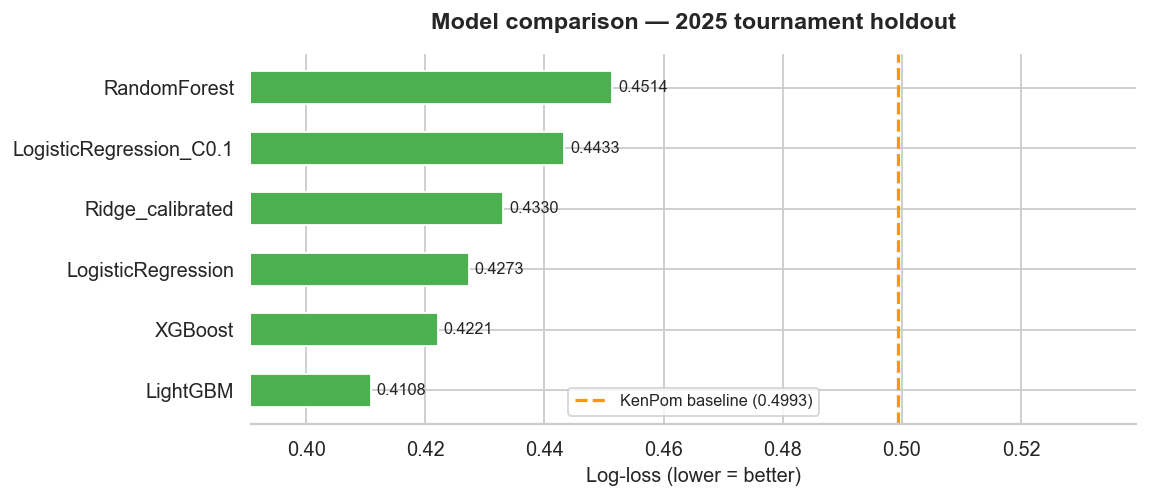

In [8]:
# Load experiment history — each line is one training run
exp_path = ROOT / "data" / "experiments.jsonl"
import json

runs = [json.loads(l) for l in exp_path.read_text().splitlines() if l.strip()]

# Flatten nested "metrics" dict into top-level columns
runs_flat = [{**{k: v for k, v in r.items() if k != "metrics"}, **r.get("metrics", {})} for r in runs]
exp_df = pd.DataFrame(runs_flat)

# Keep only 2025 holdout results (most recent full-feature run per model)
season_runs = exp_df[exp_df["test_season"] == 2025].copy()
# One row per model: keep the best (lowest log_loss) run
best_per_model = (
    season_runs.sort_values("log_loss")
    .drop_duplicates(subset="model", keep="first")
    .sort_values("log_loss")
)

kenpom_ll = best_per_model.loc[best_per_model["model"] == "KenPom_baseline", "log_loss"].iloc[0]
plot_df = best_per_model[best_per_model["model"] != "KenPom_baseline"].copy()

fig, ax = plt.subplots(figsize=(9, 4))
palette = ["#4CAF50" if ll < kenpom_ll else "#F44336" for ll in plot_df["log_loss"]]
bars = ax.barh(plot_df["model"], plot_df["log_loss"], color=palette, edgecolor="white", height=0.55)

# KenPom baseline reference line
ax.axvline(kenpom_ll, color="#FF9800", linewidth=1.8, linestyle="--", label=f"KenPom baseline ({kenpom_ll:.4f})")

for bar, val in zip(bars, plot_df["log_loss"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("Log-loss (lower = better)", fontsize=11)
ax.set_title("Model comparison — 2025 tournament holdout", fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(plot_df["log_loss"].min() - 0.02, kenpom_ll + 0.04)
ax.legend(fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.show()


## 5. 2026 Team Rankings

CarmPom's full D1 rankings for the 2026 season, sorted by AdjEM (opponent-adjusted efficiency margin). This is the headline metric — the gap in points per 100 possessions between a team's offense and defense, after accounting for strength of schedule.


In [12]:
# Pull 2026 ratings + team names from the database
with SessionLocal() as session:
    rows = (
        session.query(
            CarmPomRating.rank,
            Team.name,
            Team.conference,
            CarmPomRating.adjem,
            CarmPomRating.adjo,
            CarmPomRating.adjd,
            CarmPomRating.adjt,
            CarmPomRating.luck,
            CarmPomRating.sos,
            CarmPomRating.wins,
            CarmPomRating.losses,
        )
        .join(Team, Team.id == CarmPomRating.team_id)
        .filter(CarmPomRating.season == 2026)
        .order_by(CarmPomRating.rank)
        .all()
    )

rankings = pd.DataFrame(rows, columns=["Rank", "Team", "Conf", "AdjEM", "AdjO", "AdjD", "AdjT", "Luck", "SOS", "W", "L"])
rankings["Record"] = rankings["W"].astype(str) + "-" + rankings["L"].astype(str)

# Strip trailing " Conference" from conference names (e.g. "Big Ten Conference" -> "Big Ten")
rankings["Conf"] = rankings["Conf"].str.removesuffix(" Conference")

# Column display order — most important first
# AdjEM  : pts/100 poss margin vs avg D1 opponent (higher = better)
# AdjO   : pts scored per 100 poss vs avg D1 defense (higher = better)
# AdjD   : pts allowed per 100 poss vs avg D1 offense (lower = better)
# AdjT   : possessions per 40 min, pace-adjusted (higher = faster)
# Luck   : actual win% minus Pythagorean expected win% (positive = lucky)
# SOS    : avg AdjEM of opponents faced
display_cols = ["Rank", "Team", "Conf", "Record", "AdjEM", "AdjO", "AdjD", "AdjT", "Luck", "SOS"]

print(f"Total teams rated: {len(rankings)}")
rankings[display_cols].head(50).style \
    .background_gradient(subset=["AdjEM"], cmap="RdYlGn") \
    .background_gradient(subset=["AdjO"], cmap="Greens") \
    .background_gradient(subset=["AdjD"], cmap="Reds_r") \
    .background_gradient(subset=["Luck"], cmap="coolwarm") \
    .background_gradient(subset=["SOS"], cmap="Purples") \
    .format({
        "AdjEM": "{:+.2f}",
        "AdjO":  "{:.2f}",
        "AdjD":  "{:.2f}",
        "AdjT":  "{:.1f}",
        "Luck":  "{:+.3f}",
        "SOS":   "{:+.2f}",
    }) \
    .set_caption(
        "CarmPom 2026 — Top 50 Teams  |  "
        "AdjEM = pts/100 poss margin  |  AdjO = off. efficiency  |  "
        "AdjD = def. efficiency (lower=better)  |  AdjT = tempo  |  "
        "Luck = actual W% − expected W%"
    )


Total teams rated: 365


,Rank,Team,Conf,Record,AdjEM,AdjO,AdjD,AdjT,Luck,SOS
0,1,Michigan Wolverines,Big Ten,29-2,+46.83,133.59,86.76,73.0,+0.009,+20.70
1,2,Duke Blue Devils,Atlantic Coast,30-2,+46.21,132.44,86.23,66.8,-0.005,+17.11
2,3,Arizona Wildcats,Big 12,30-2,+42.17,129.19,87.02,71.5,+0.019,+17.24
3,4,Illinois Fighting Illini,Big Ten,24-7,+40.52,134.98,94.45,67.4,-0.110,+16.98
4,5,Florida Gators,Southeastern,25-6,+39.52,128.65,89.14,71.5,-0.081,+18.01
5,6,Houston Cougars,Big 12,27-5,+38.58,127.15,88.57,64.7,-0.052,+15.80
6,7,Iowa State Cyclones,Big 12,27-6,+38.47,127.48,89.01,68.1,-0.100,+14.38
7,8,Purdue Boilermakers,Big Ten,24-8,+37.46,134.68,97.22,66.0,-0.077,+19.14
8,9,Gonzaga Bulldogs,West Coast,30-3,+35.37,124.50,89.13,70.3,-0.022,+8.65
9,10,UConn Huskies,Big East,28-4,+34.48,125.64,91.16,66.4,+0.005,+14.50


## 6. Top 25 Rankings — Visual


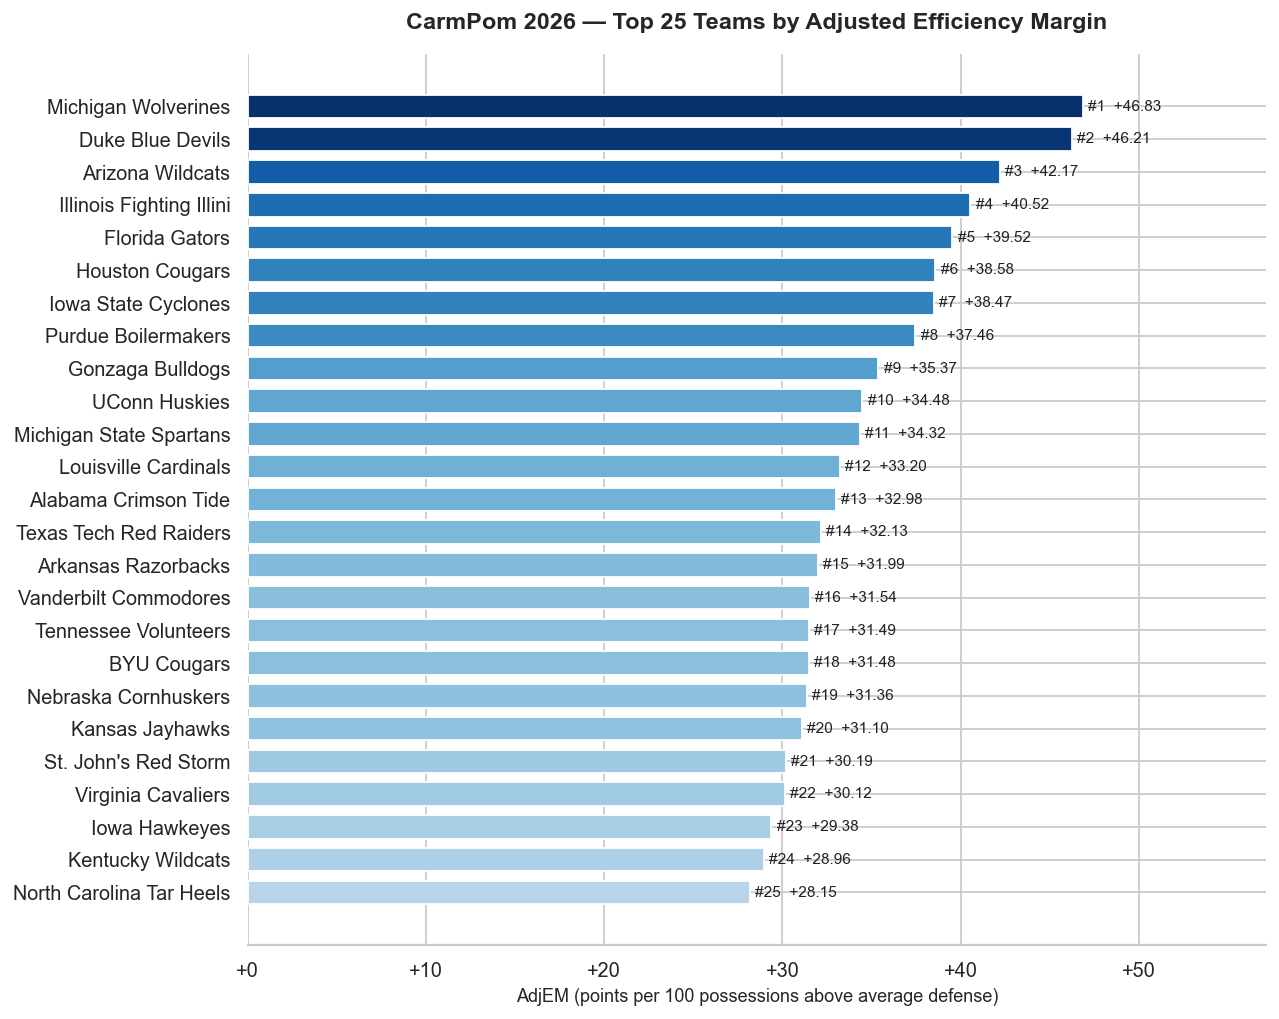

In [13]:
top25 = rankings.head(25).sort_values("AdjEM", ascending=True)

# Color gradient: deeper blue = higher ranked
norm = plt.Normalize(top25["AdjEM"].min(), top25["AdjEM"].max())
colors = plt.cm.Blues(norm(top25["AdjEM"].values) * 0.7 + 0.3)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top25["Team"], top25["AdjEM"], color=colors, edgecolor="white", height=0.72)

# Annotate with rank and AdjEM value
for bar, (_, row) in zip(bars, top25.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"#{int(row['Rank'])}  {row['AdjEM']:+.2f}",
        va="center", fontsize=8.5, color="#222",
    )

ax.set_xlabel("AdjEM (points per 100 possessions above average defense)", fontsize=10)
ax.set_title("CarmPom 2026 — Top 25 Teams by Adjusted Efficiency Margin",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(0, top25["AdjEM"].max() * 1.22)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%+.0f"))
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()
